# Simple Chatbot with LangGraph and LLM

Build a simple chatbot using LangGraph and an LLM that can receive user messages, maintain them as graph state, process the messages through a chatbot node, and generate AI-powered responses. The chatbot should also demonstrate graph visualization, message reducers, graph invocation, and response streaming using different streaming modes.

## Importing Required Libraries

### LangGraph State and Reducer Imports

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

### Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

### Environment Variable Setup

In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

### Importing ChatOpenAI

In [ ]:
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

### Importing ChatGroq

In [11]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="openai/gpt-oss-120b")
llm_groq.invoke("Hey, I am Dev and I am a big fan of Iron Man.")

AIMessage(content='Hey Dev! That’s awesome—Iron\u202fMan is such an iconic hero. Do you have a favorite movie, scene, or piece of tech from the Iron\u202fMan universe? I’m curious to hear what draws you to Tony Stark! 🚀🦾', additional_kwargs={'reasoning_content': 'The user says: "Hey, I am Dev and I am a big fan of Iron\xa0Man." It\'s a simple statement. We should respond appropriately. There\'s no disallowed content. We can engage in friendly conversation, ask about favorite Iron Man movies, etc. The user introduced themselves as Dev. We can respond acknowledging and maybe ask a question. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 137, 'prompt_tokens': 86, 'total_tokens': 223, 'completion_time': 0.283809095, 'completion_tokens_details': {'reasoning_tokens': 75}, 'prompt_time': 0.004324443, 'prompt_tokens_details': None, 'queue_time': 0.396182535, 'total_time': 0.288133538}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_803c0ba83d', 'se

## Creating the State Schema Using Annotated with add_messages

In [9]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

## Creating the Chatbot Node

In [14]:
### Creating Nodes

def superbot(state:State):
    return {"messages":[llm_groq.invoke(state["messages"])]}

## Building the LangGraph

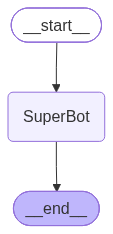

In [ ]:
graph=StateGraph(State)

### Adding the Node
graph.add_node("SuperBot", superbot)

### Adding Graph Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

### Compiling the Graph
graph_builder=graph.compile()

### Displaying the Graph
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

## Invoking the Chatbot

### Passing Messages to the Graph

In [ ]:
graph_builder.invoke({"messages":"Hi, My name is Dev. I am big fan of Iron Man"})

{'messages': [HumanMessage(content='Hi, My name is Dev. I am big fan of Iron Man', additional_kwargs={}, response_metadata={}, id='c896cce9-05a1-442b-b23f-011ac42c6ed8'),
  AIMessage(content='Hey Dev! Great to meet a fellow Iron\u202fMan fan. 🦾✨  \nWhat’s your favorite suit or moment from the movies (or the comics)? If there’s anything you’d like to chat about—whether it’s Tony Stark’s tech, a favorite quote, or something else entirely—just let me know!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Dev. I am big fan of Iron\xa0Man". This is a greeting and self-introduction. We should respond politely, perhaps ask how we can help, maybe talk about Iron Man. There\'s no policy violation. So respond friendly, maybe ask about favorite Iron Man movies, etc.'}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 85, 'total_tokens': 228, 'completion_time': 0.298434054, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0

## Streaming the Chatbot Responses

### Basic Streaming

In [ ]:
graph_builder.stream({"messages":"Hello, My name is Dev."})

<generator object Pregel.stream at 0x000001C858BE08F0>

In [ ]:
for event in graph_builder.stream({"messages":"Hello, My name is Dev."}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hello Dev! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello, My name is Dev." Probably wants a greeting. Should respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 78, 'total_tokens': 127, 'completion_time': 0.101635011, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.029395596, 'prompt_tokens_details': None, 'queue_time': 0.39576708, 'total_time': 0.131030607}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e3b5-7474-73a1-b9b6-a38f1c137097-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 49, 'total_tokens': 127, 'output_token_details': {'reasoning': 25}})]}}


### Streaming with stream_mode="values"

In [24]:
for event in graph_builder.stream({"messages":"Hello, My name is Dev."}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello, My name is Dev.', additional_kwargs={}, response_metadata={}, id='8f0fe3c0-01c2-46fd-9e6b-295ad30ab9c3')]}
{'messages': [HumanMessage(content='Hello, My name is Dev.', additional_kwargs={}, response_metadata={}, id='8f0fe3c0-01c2-46fd-9e6b-295ad30ab9c3'), AIMessage(content='Hello, Dev! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hello, My name is Dev." The system says we must follow policies. There\'s no disallowed content. We can greet back. Maybe ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 78, 'total_tokens': 146, 'completion_time': 0.142493189, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003323184, 'prompt_tokens_details': None, 'queue_time': 0.211830854, 'total_time': 0.145816373}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_86dc843b12', 'service_tier': 'on_d

### Streaming with stream_mode="updates"

In [25]:
for event in graph_builder.stream({"messages":"Hello, My name is Dev."}, stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hello, Dev! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello, My name is Dev." The system message says we must be ChatGPT, and we have a developer message: "You are ChatGPT..." The user greeting. We should respond politely, greeting back, maybe ask how can help. No disallowed content. So answer friendly.'}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 78, 'total_tokens': 165, 'completion_time': 0.183218917, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.003900815, 'prompt_tokens_details': None, 'queue_time': 0.395085133, 'total_time': 0.187119732}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e3bf-43cc-70d1-a77a-673cd353f45a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=